In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
user = pd.read_csv("users.csv")

In [3]:
user

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,12,19000,0
1,15810944,Male,11,20000,0
2,15668575,Female,1,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,10,76000,0
...,...,...,...,...,...
94,15786993,Female,45,83000,0
95,15709441,Female,35,44000,0
96,15710257,Female,4,25000,0
97,15582492,Male,5,123000,1


In [4]:
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          99 non-null     int64 
 1   Gender           99 non-null     object
 2   Age              99 non-null     int64 
 3   EstimatedSalary  99 non-null     int64 
 4   Purchased        99 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 4.0+ KB


In [5]:
user['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [6]:
user['Purchased'].unique()

array([0, 1])

In [7]:
user.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,12,19000,0
1,15810944,Male,11,20000,0
2,15668575,Female,1,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,10,76000,0


In [8]:
user['Age'].min()

1

In [10]:
user['Age'].max()

64

In [11]:
user['EstimatedSalary'].min()

15000

In [12]:
user['EstimatedSalary'].max()

150000

In [13]:
X = user.columns.drop('Purchased')
y = user['Purchased']

In [15]:
user_decode = pd.get_dummies(user[X]).astype(int)

In [17]:
user_decode

,User ID,Age,EstimatedSalary,max,Gender_Female,Gender_Male
0,15624510,12,19000,64,0,1
1,15810944,11,20000,64,0,1
2,15668575,1,43000,64,1,0
3,15603246,27,57000,64,1,0
4,15804002,10,76000,64,0,1
...,...,...,...,...,...,...
94,15786993,45,83000,64,1,0
95,15709441,35,44000,64,1,0
96,15710257,4,25000,64,1,0
97,15582492,5,123000,64,0,1


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x_train, x_test, y_train, y_test = train_test_split(user_decode, y, test_size=0.2, random_state=0)

In [20]:
x_train.shape

(79, 6)

In [21]:
x_test.shape

(20, 6)

In [23]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini', random_state=1)
model.fit(x_train, y_train) 

DecisionTreeClassifier(random_state=1)

In [24]:
test_pred = model.predict(x_train)
test_pred = model.predict(x_test)

[Text(0.6785714285714286, 0.9375, 'x[2] <= 117500.0\ngini = 0.275\nsamples = 79\nvalue = [66, 13]'),
 Text(0.6071428571428571, 0.8125, 'x[2] <= 30500.0\ngini = 0.193\nsamples = 74\nvalue = [66, 8]'),
 Text(0.35714285714285715, 0.6875, 'x[0] <= 15652305.0\ngini = 0.393\nsamples = 26\nvalue = [19, 7]'),
 Text(0.21428571428571427, 0.5625, 'x[2] <= 19500.0\ngini = 0.5\nsamples = 12\nvalue = [6, 6]'),
 Text(0.14285714285714285, 0.4375, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.2857142857142857, 0.4375, 'x[1] <= 13.0\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.21428571428571427, 0.3125, 'x[2] <= 21000.0\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.14285714285714285, 0.1875, 'x[0] <= 15635218.0\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.07142857142857142, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.21428571428571427, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2857142857142857, 0.1875, 'gini = 0.0\nsamples = 5\nvalue = [0, 

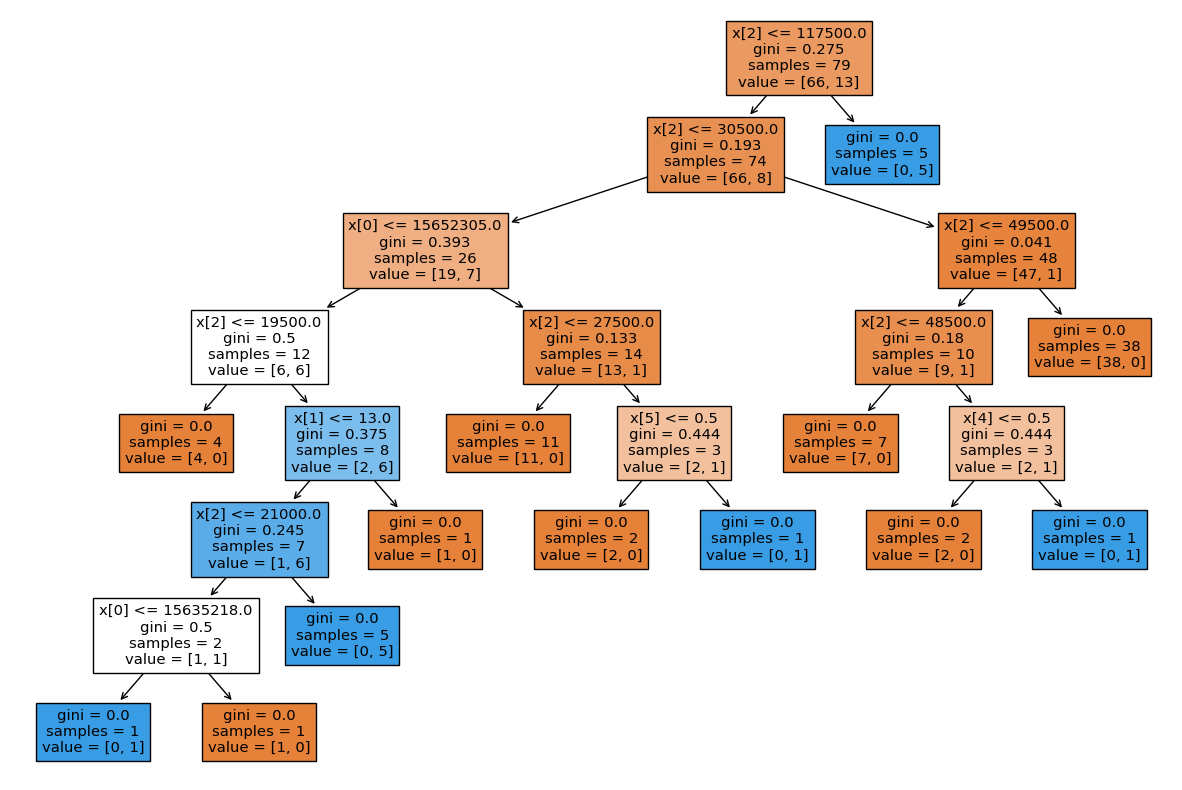

In [25]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,10))
plot_tree(model, filled=True)

In [26]:
plt.show()

In [29]:
train_accuracy = model.score(x_train, y_train)
test_accuracy = model.score(x_test, y_test)
print(train_accuracy)
print(test_accuracy)

1.0
0.8


In [30]:
import warnings
from sklearn.metrics import accuracy_score, classification_report
warnings.filterwarnings("ignore")


In [31]:
data = pd.read_csv("spambase.csv")

In [37]:
data

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_req_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [38]:
from  sklearn.model_selection import train_test_split
features=data.columns.drop('spam')
target='spam'
X=data[features]
Y=data[target]
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=100)

In [39]:
X = data.iloc[:,:-1]
Y = data.iloc[:,-1]

In [40]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=10,min_samples_split=20,min_impurity_decrease=0.05)
model.fit(x_train,y_train)
train_accuracy = model.score(x_train,y_train)
test_accuray = model.score(x_test,y_test)

In [41]:
print(test_accuray)
print(train_accuracy)

0.8642779587404995
0.8600543478260869


In [ ]:
#Algoritnam :- Boosting

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(n_estimators=10)
model.fit(x_train, y_train)
train_accuracy1 = model.score(x_train, y_train)
test_accuracy1 = model.score(x_test, y_test)
print(train_accuracy1)
print(test_accuracy1)

0.9195652173913044
0.9272529858849077


In [43]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", report)

Accuracy: 0.9272529858849077
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       546
           1       0.94      0.88      0.91       375

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921

